# Phân tích hiệu năng khối phát hiện khuôn mặt

**Nguồn dữ liệu:** `results/bench_detect_20260819_1453.csv` — sinh bởi
`scripts/benchmark_detect.py` (mã việc `P2-03`).

---

## ⚠️ Số liệu ở đây ĐO TRÊN MÁY PHÁT TRIỂN, KHÔNG PHẢI Raspberry Pi 5

Theo `.claude/instructions/experiment-protocol.instructions.md` §2, mọi chỉ số FPS và độ trễ
đưa vào báo cáo **bắt buộc** đo trên phần cứng đích thật. Notebook này phục vụ ba mục đích:

1. Kiểm chứng quy trình phân tích chạy đúng trước khi có phần cứng
2. Hiểu cấu trúc dữ liệu, chọn biểu đồ nào đáng đưa vào báo cáo
3. Sẵn sàng chạy lại ngay khi có tệp đo từ Pi 5 — chỉ đổi một dòng ở ô dưới

**Không hình nào trong notebook này được đưa vào báo cáo.** Hình chính thức sinh từ
`scripts/plot_*.py` theo chuẩn `latex-visualization`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Đổi dòng này khi có tệp đo từ Raspberry Pi 5
TEP_CSV = Path('../results/bench_detect_20260819_1453.csv')

TEP_META = TEP_CSV.parent / (TEP_CSV.stem + '.meta.json')

# Kiểu vẽ tối giản, đọc được khi in đen trắng (latex-visualization)
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True,
})

df = pd.read_csv(TEP_CSV)
meta = json.loads(TEP_META.read_text(encoding='utf-8'))
luong = sorted(df.threads.unique())
kich_thuoc = sorted(df.imgsz.unique())
print(len(df), 'dòng đo |', len(kich_thuoc), 'độ phân giải ×', len(luong), 'mức luồng')


600 dòng đo | 2 độ phân giải × 3 mức luồng


## 1. Ngữ cảnh phép đo

R8 đòi mọi số đo phải kèm ngữ cảnh. Ô dưới đọc từ `.meta.json`. Nếu có cảnh báo container
thì số liệu **không dùng được** — container chạy qua giả lập nên thời gian không quy đổi được.


In [2]:
print('Thiết bị    :', meta['device']['name'])
print('Hệ điều hành:', meta['device']['os'])
print('Kiến trúc   :', meta['device']['machine'])
print('Commit      :', meta['git_commit'][:12], '| cây làm việc bẩn:', meta['git_dirty'])
print('Seed        :', meta['seed'], '| khung làm nóng:', meta['warmup_frames'])
print('Thư viện    :', meta['software'])

if 'canh_bao_hieu_nang' in meta:
    print()
    print('*** CẢNH BÁO ***')
    print(meta['canh_bao_hieu_nang'])
    print('=> KHÔNG dùng số này làm số hiệu năng.')
else:
    print()
    print('Không có cảnh báo container.')


Thiết bị    : PC phát triển
Hệ điều hành: Windows-11-10.0.26200-SP0
Kiến trúc   : AMD64
Commit      : 86df4fcce250 | cây làm việc bẩn: True
Seed        : 42 | khung làm nóng: 10
Thư viện    : {'python': '3.12.5', 'onnxruntime': '1.20.1', 'opencv-python': '4.13.0', 'numpy': '2.2.0'}

Không có cảnh báo container.


## 2. Bảng tổng hợp theo cấu hình

Trung bình kèm độ lệch chuẩn (R9), thêm phân vị 50 và 95.
Phân vị 95 quan trọng hơn trung bình với hệ thống thời gian thực: nó cho biết **trường hợp
xấu** chứ không phải trường hợp điển hình.


In [3]:
tom_tat = (df.groupby(['imgsz', 'threads'])
             .agg(so_khung=('latency_ms', 'size'),
                  lat_tb=('latency_ms', 'mean'),
                  lat_do_lech=('latency_ms', 'std'),
                  lat_p50=('latency_ms', lambda s: np.percentile(s, 50)),
                  lat_p95=('latency_ms', lambda s: np.percentile(s, 95)),
                  ti_le_phat_hien=('n_faces', lambda s: (s >= 1).mean()))
             .round(2))
tom_tat['fps_tb'] = (1000 / tom_tat.lat_tb).round(2)
tom_tat['dat_10fps'] = np.where(tom_tat.fps_tb >= 10, 'Đạt', 'KHÔNG')
tom_tat


so_khung  lat_tb  lat_do_lech  lat_p50  lat_p95  \
imgsz threads                                                    
320   1             100   64.42         7.73    65.87    74.44   
      2             100   49.45         9.90    50.63    65.44   
      4             100   47.62         7.93    47.99    60.49   
640   1             100  256.52        30.61   257.46   303.71   
      2             100  198.27        26.07   198.87   232.88   
      4             100  226.60       104.37   184.54   489.93   

               ti_le_phat_hien  fps_tb dat_10fps  
imgsz threads                                     
320   1                    1.0   15.52       Đạt  
      2                    1.0   20.22       Đạt  
      4                    1.0   21.00       Đạt  
640   1                    1.0    3.90     KHÔNG  
      2                    1.0    5.04     KHÔNG  
      4                    1.0    4.41     KHÔNG

## 3. Tốc độ khung hình theo cấu hình

Đường ngang đứt nét là chỉ tiêu cam kết **≥ 10 FPS** cho khối phát hiện.


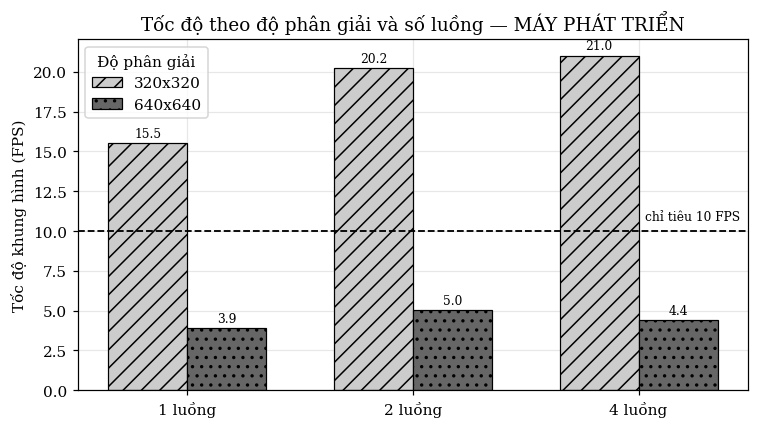

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(luong))
rong = 0.35
hoa_tiet = ['//', '..']
mau_cot = ['#cccccc', '#666666']

for i, k in enumerate(kich_thuoc):
    fps = [1000 / df[(df.imgsz == k) & (df.threads == t)].latency_ms.mean() for t in luong]
    ax.bar(x + (i - 0.5) * rong, fps, rong, label=str(k) + 'x' + str(k),
           edgecolor='black', linewidth=0.8, hatch=hoa_tiet[i], color=mau_cot[i])
    for xi, v in zip(x + (i - 0.5) * rong, fps):
        ax.text(xi, v + 0.4, format(v, '.1f'), ha='center', fontsize=8)

ax.axhline(10, color='black', linestyle='--', linewidth=1.2)
ax.text(len(luong) - 0.55, 10.7, 'chỉ tiêu 10 FPS', ha='right', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([str(t) + ' luồng' for t in luong])
ax.set_ylabel('Tốc độ khung hình (FPS)')
ax.set_title('Tốc độ theo độ phân giải và số luồng — MÁY PHÁT TRIỂN')
ax.legend(title='Độ phân giải')
plt.tight_layout()
plt.show()


### Nhận xét

- **640 trượt chỉ tiêu ở mọi mức luồng**, ngay trên máy để bàn vốn mạnh hơn Pi 5 nhiều.
- **Ở 640, bốn luồng chậm hơn hai luồng.** Tăng luồng không phải lúc nào cũng nhanh hơn —
  chi phí đồng bộ và tranh chấp băng thông bộ nhớ có thể lấn át phần lợi.

Cả hai **chưa phải kết luận của đồ án**: Pi 5 có kiến trúc bộ nhớ và tản nhiệt khác hẳn.


## 4. Phân bố độ trễ

Trung bình che giấu độ ổn định. Biểu đồ hộp cho thấy mức dao động — thứ quyết định hệ thống
thời gian thực có giữ được nhịp hay không.


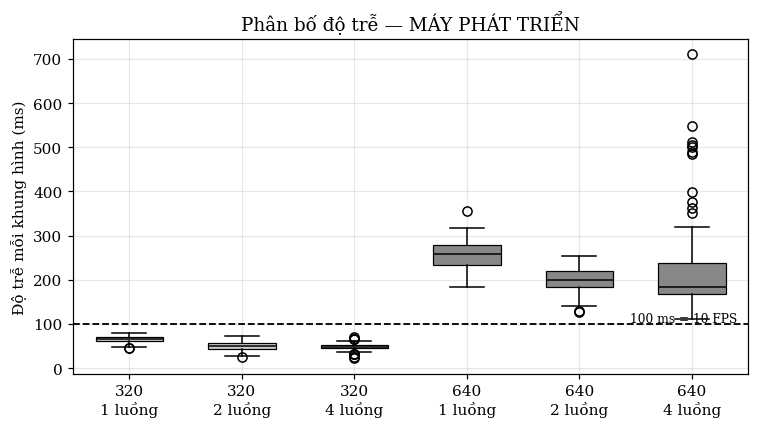

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
nhom, nhan = [], []
for k in kich_thuoc:
    for t in luong:
        nhom.append(df[(df.imgsz == k) & (df.threads == t)].latency_ms.values)
        nhan.append(str(k) + '\n' + str(t) + ' luồng')

bp = ax.boxplot(nhom, tick_labels=nhan, patch_artist=True, widths=0.6)
for i, hop in enumerate(bp['boxes']):
    hop.set(facecolor='#cccccc' if i < len(luong) else '#888888', linewidth=0.8)
for ten_bo_phan in ['medians', 'whiskers', 'caps']:
    for v in bp[ten_bo_phan]:
        v.set(color='black', linewidth=1.0)

ax.axhline(100, color='black', linestyle='--', linewidth=1.2)
ax.text(len(nhan) + 0.4, 104, '100 ms = 10 FPS', ha='right', fontsize=8)
ax.set_ylabel('Độ trễ mỗi khung hình (ms)')
ax.set_title('Phân bố độ trễ — MÁY PHÁT TRIỂN')
plt.tight_layout()
plt.show()


## 5. Độ trễ theo thời gian trong một lần đo

Trung bình và độ lệch chuẩn không cho biết latency **biến động theo trật tự nào**. Biểu đồ dưới vẽ
trung bình trượt theo thứ tự khung hình, và ô sau định lượng chênh lệch giữa 20 khung đầu với 20
khung cuối của mỗi ô ma trận.

Bối cảnh: ở vòng review `P2-03`, số đo của script chậm hơn mốc đo lúc máy nguội tới 20-45 %, và ban
đầu bị nghi là chi phí ẩn trong mã. Người review bác bỏ giả thuyết đó bằng kiểm toán ngân sách thời
gian, rồi tái lập được mốc cũ bằng cách **để máy nghỉ 90-120 giây trước khi đo một ô đơn lẻ**. Kết
luận: chênh lệch đến từ **trạng thái nhiệt của máy**, không từ mã nguồn.

**Lưu ý khi đọc số ở ô dưới.** Dữ liệu hiện có **không cho thấy xu hướng tăng nhất quán** trong từng
ô: hai ô nhanh lên, bốn ô chậm đi, mức chênh từ -18 % tới +20 %. Ba nguyên nhân có thể trộn lẫn:
turbo của CPU ổn định dần ở ô chạy đầu, nhiệt tích luỹ qua các ô, và nhiễu đo vốn lớn - riêng ô
640 với 4 luồng có độ lệch chuẩn tới 104 ms.

Nói cách khác, **bằng chứng về ảnh hưởng nhiệt đến từ phép đo có kiểm soát của vòng review, không
đến từ bảng dưới đây.** Bảng dưới chỉ cho thấy latency biến động đáng kể trong một lần đo, đủ để
kết luận rằng một con số trung bình đơn lẻ không mô tả hết hành vi của hệ thống.

Hệ quả cho đồ án vẫn giữ nguyên: số đo lần chạy đầu trên máy nguội **đẹp hơn thực tế**. Raspberry
Pi 5 chạy liên tục trong nhà, tản nhiệt kém hơn hẳn, nên con số đưa vào báo cáo phải là **số ổn
định**. Đó chính là lý do bước 2.7 yêu cầu theo dõi nhiệt độ và throttling 10 phút liên tục.


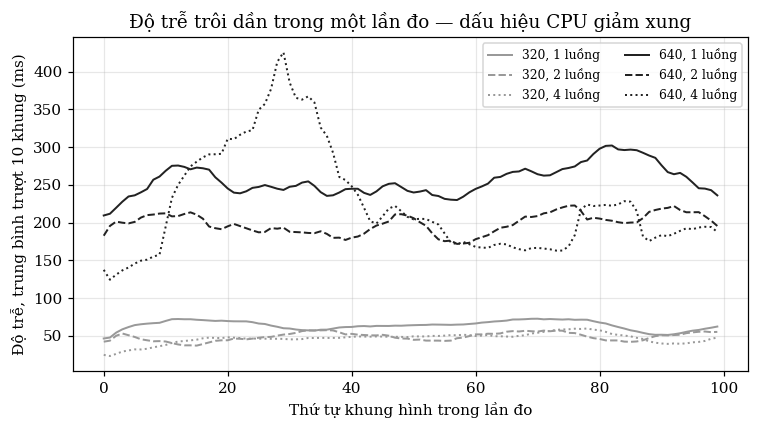

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
kieu_net = ['-', '--', ':']

for k, mau in zip(kich_thuoc, ['#999999', '#222222']):
    for j, t in enumerate(luong):
        g = df[(df.imgsz == k) & (df.threads == t)].sort_values('sample_idx')
        truot = g.latency_ms.rolling(10, min_periods=1).mean()
        ax.plot(g.sample_idx.values, truot.values, kieu_net[j], color=mau,
                linewidth=1.3, label=str(k) + ', ' + str(t) + ' luồng')

ax.set_xlabel('Thứ tự khung hình trong lần đo')
ax.set_ylabel('Độ trễ, trung bình trượt 10 khung (ms)')
ax.set_title('Độ trễ trôi dần trong một lần đo — dấu hiệu CPU giảm xung')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


In [7]:
# Định lượng mức trôi: 20 khung đầu so với 20 khung cuối
print('cấu hình'.ljust(20), '20 đầu'.rjust(9), '20 cuối'.rjust(10), 'trôi'.rjust(9))
print('-' * 50)
for k in kich_thuoc:
    for t in luong:
        g = df[(df.imgsz == k) & (df.threads == t)].sort_values('sample_idx').latency_ms.values
        dau, cuoi = g[:20].mean(), g[-20:].mean()
        ten = str(k) + ', ' + str(t) + ' luồng'
        print(ten.ljust(20), format(dau, '9.1f'), format(cuoi, '10.1f'),
              format((cuoi - dau) / dau * 100, '8.1f') + '%')


cấu hình                20 đầu    20 cuối      trôi
--------------------------------------------------
320, 1 luồng              68.7       56.8    -17.3%
320, 2 luồng              43.5       52.4     20.4%
320, 4 luồng              41.6       44.3      6.3%
640, 1 luồng             257.1      261.0      1.5%
640, 2 luồng             201.7      206.2      2.2%
640, 4 luồng             224.4      183.9    -18.1%


## 6. Chất lượng phát hiện

Tốc độ chỉ có ý nghĩa nếu mô hình thực sự tìm ra khuôn mặt.


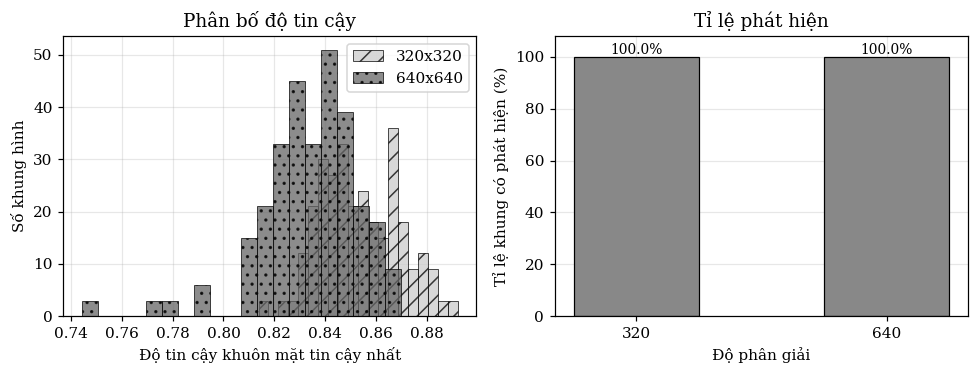

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

for k, mau, ht in zip(kich_thuoc, ['#cccccc', '#666666'], ['//', '..']):
    c = df[df.imgsz == k].conf_top.dropna()
    ax1.hist(c, bins=20, alpha=0.75, label=str(k) + 'x' + str(k), color=mau,
             edgecolor='black', linewidth=0.6, hatch=ht)
ax1.set_xlabel('Độ tin cậy khuôn mặt tin cậy nhất')
ax1.set_ylabel('Số khung hình')
ax1.legend()
ax1.set_title('Phân bố độ tin cậy')

ti_le = df.groupby('imgsz').n_faces.apply(lambda s: (s >= 1).mean() * 100)
ax2.bar([str(i) for i in ti_le.index], ti_le.values, 0.5,
        color='#888888', edgecolor='black', linewidth=0.8)
for i, v in enumerate(ti_le.values):
    ax2.text(i, v + 1.0, format(v, '.1f') + '%', ha='center', fontsize=9)
ax2.set_ylim(0, 108)
ax2.set_xlabel('Độ phân giải')
ax2.set_ylabel('Tỉ lệ khung có phát hiện (%)')
ax2.set_title('Tỉ lệ phát hiện')
plt.tight_layout()
plt.show()


## 7. Kết luận tạm thời

Ba điều rút ra, **tất cả chỉ áp dụng cho máy phát triển**:

| Quan sát | Ý nghĩa cho bước tiếp theo |
|---|---|
| 640 dưới 10 FPS ở mọi mức luồng | Chuẩn bị phương án chốt 320, nhưng phải đo lại trên Pi 5 mới kết luận |
| 4 luồng không luôn nhanh hơn 2 luồng | Giữ nguyên cả ba mức luồng trong ma trận đo, đừng cắt bớt |
| Độ trễ trôi trong một lần đo | Bước 2.7 phải đo ở trạng thái nhiệt ổn định, không lấy số lần chạy đầu |

### Việc cần làm khi có Raspberry Pi 5

1. Chạy `scripts/benchmark_detect.py --device-name "Raspberry Pi 5 8GB"` trên máy thật
2. Đổi `TEP_CSV` ở ô đầu notebook này sang tệp mới, chạy lại toàn bộ
3. Đối chiếu với bảng ở mục 2 để thấy khoảng cách giữa máy để bàn và thiết bị đích
4. Viết `scripts/plot_detect_fps.py` sinh hình chính thức cho báo cáo từ tệp đo của Pi 5
